In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

In [9]:
sns.set_style("whitegrid")
url = "https://raw.githubusercontent.com/imgraham1/539_FinalProject/master/world-happiness-report-2019.csv"
df = pd.read_csv(url)

rank_cols = ['Social_support','Freedom','Corruption','Generosity',
             'Log_of_GDP_per_capita','Healthy_life_expectancy']
for col in rank_cols:
    df[col] = 157 - df[col]

impute_cols = ['Positive_affect','Negative_affect','Social_support','Freedom',
               'Corruption','Generosity','Log_of_GDP_per_capita','Healthy_life_expectancy']
for col in impute_cols:
    df[col] = df[col].fillna(df[col].median())

In [10]:
median_ladder = df['Ladder'].median()
df['high_happiness'] = (df['Ladder'] > median_ladder).astype(int)
features = ['Log_of_GDP_per_capita', 'Freedom', 'Corruption',
            'Generosity', 'Healthy_life_expectancy']
X = df[features]
y = df['high_happiness']

print("Feature summary:\n", X.describe())
print("\nTarget balance:\n", y.value_counts())

Feature summary:
        Log_of_GDP_per_capita     Freedom  Corruption  Generosity  \
count             156.000000  156.000000  156.000000  156.000000   
mean               80.500000   79.000000   82.500000   79.000000   
std                43.450973   44.743715   41.747088   44.743715   
min                 5.000000    2.000000    9.000000    2.000000   
25%                43.750000   40.750000   47.750000   40.750000   
50%                80.500000   79.000000   82.500000   79.000000   
75%               117.250000  117.250000  117.250000  117.250000   
max               156.000000  156.000000  156.000000  156.000000   

       Healthy_life_expectancy  
count               156.000000  
mean                 81.500000  
std                  42.596191  
min                   7.000000  
25%                  45.750000  
50%                  81.500000  
75%                 117.250000  
max                 156.000000  

Target balance:
 high_happiness
1    78
0    78
Name: count, dtype: int

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train size:", X_train.shape[0], "Test size:", X_test.shape[0])

Train size: 124 Test size: 32


In [12]:
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

coef_df = pd.DataFrame({'Feature': features, 'Coefficient': model.coef_[0]})
print(coef_df.sort_values('Coefficient', ascending=False))

                   Feature  Coefficient
4  Healthy_life_expectancy     1.547592
0    Log_of_GDP_per_capita     1.407901
1                  Freedom     0.864134
3               Generosity     0.384585
2               Corruption     0.033526


In [14]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall:    {rec:.3f}")
print(f"F1-score:  {f1:.3f}")
print("\nFull classification report:\n", classification_report(y_test, y_pred))
train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
print(f"\nTrain accuracy: {train_acc:.3f}  |  Test accuracy: {acc:.3f}")

Accuracy:  0.812
Precision: 0.812
Recall:    0.812
F1-score:  0.812

Full classification report:
               precision    recall  f1-score   support

           0       0.81      0.81      0.81        16
           1       0.81      0.81      0.81        16

    accuracy                           0.81        32
   macro avg       0.81      0.81      0.81        32
weighted avg       0.81      0.81      0.81        32


Train accuracy: 0.879  |  Test accuracy: 0.812


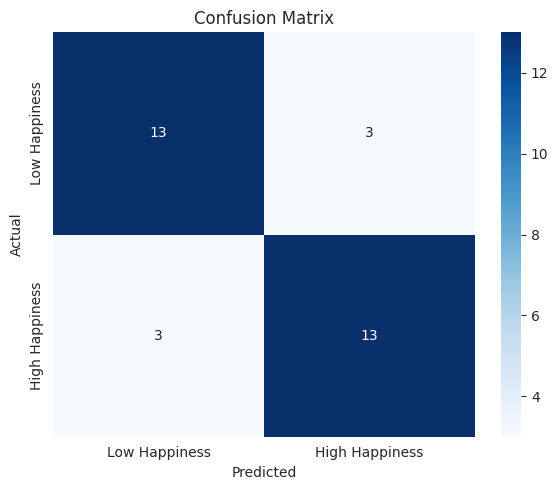

In [15]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low Happiness','High Happiness'],
            yticklabels=['Low Happiness','High Happiness'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

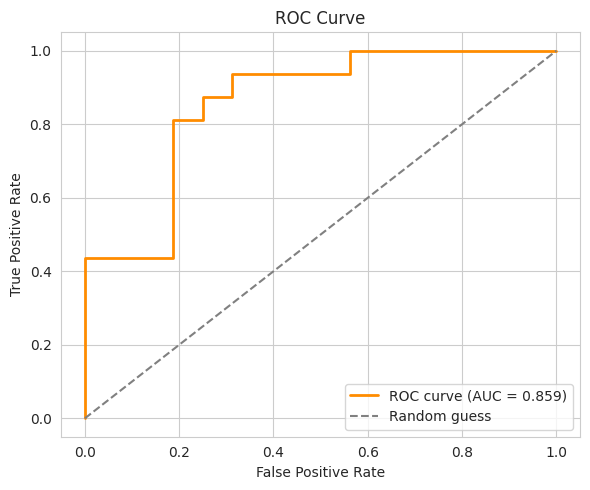

In [18]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0,1],[0,1], color='gray', linestyle='--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve.png')
plt.show()

In [19]:
from google.colab import files
for f in ["confusion_matrix.png", "roc_curve.png"]:
    files.download(f)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>